# Gewöhnliche Differentialgleichungen 

Zur numerischen Lösung eines Anfangswertproblems

$$
    y' = f(x, y), \quad y(x_0) = y_0
$$

auf einem Intervall $x \in [x_0, x_n]$ wird eine Folge von Punkten $(x_k, y_k)$ konstruiert, die die Lösung annähern.

## Eulers Methoden

### Eulers explizite Methode
Die **explizite Methode von Euler** (aka **Euler vorwärts**) bestimmt die Folge der Punkte gemäss

$$
    y(x_0) = y_0, \quad x_{k+1} = x_k + h, \quad y_{k+1} = y_k + h \cdot f(x_k, y_k), \quad (k = 0, 1, \ldots, n)
$$

Die Schrittweite $h$ muss nicht zwingend in jedem Schritt gleich sein. Wegen 

$$
    y'(x_k) = f(x_k, y_k) \quad \implies \quad y_{k+1} = y_k + h \cdot y'(x_k)
$$

folgt die Methode von jedem Stützpunkt $(x_k, y_k)$ aus der Tangenten an die Lösungskurve durch $(x_k, y_k)$




Das folgende Beispiel illustriert die Methode am AWP
$$
    y' = \sin(x + y), \quad y(1) = 1
$$

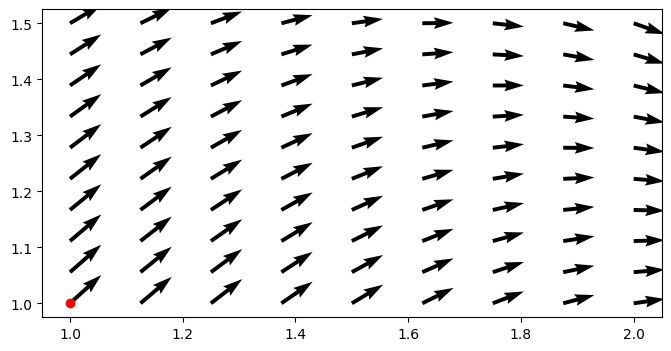

In [61]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp

f   = lambda x, y :  np.sin(x+y)  # y' = f(x, y)
d2f = lambda x, y :  np.cos(x+y)  # partielle Ableitung df / dy. Wird für die implizite Eulermethode verwendet

# Darstellung des Vektorfeldes
u = lambda x, y: np.ones(x.shape)    # für Darstellung des Vektorfeldes: x' = 1
v = lambda x, y: f(x,y)              # ebenso y' = f(x, y)

x, y = np.linspace(1,2,9), np.linspace(1, 1.5, 10)

X, Y = np.meshgrid(x,y)

plt.figure(figsize = (8, 4))
plt.quiver(X, Y, u(X,Y), v(X,Y), angles = 'xy', linewidth = .5)

y0 = 1
x0 = x[0]
plt.scatter(x0, y0, color = "r")


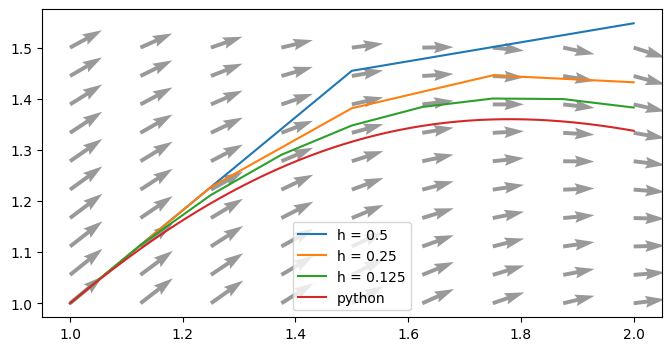

In [65]:
plt.figure(figsize = (8, 4))
plt.quiver(X, Y, u(X,Y), v(X,Y), angles = 'xy', linewidth = .25, color = [.6,.6,.6])

#%% Euler (vorwärts) Achtung: es ist nicht garantiert, dass die Endstelle xn exakt getroffen wird!
def eulerExplizit(f, x0, y0, xn, h):
    
    x = [x0]
    y = [y0]
    
    while x[-1] < xn-h/2:        
        y.append(y[-1] + h * f(x[-1], y[-1]) )
        x.append(x[-1] + h)
    return np.array(x), np.array(y)
 
xe1, ye1 = eulerExplizit(f = f, x0 = x0, y0 = y0, xn = x[-1], h = .5)
xe2, ye2 = eulerExplizit(f = f, x0 = x0, y0 = y0, xn = x[-1], h = .25)
xe3, ye3 = eulerExplizit(f = f, x0 = x0, y0 = y0, xn = x[-1], h = .125)

sol = solve_ivp(f, [x0, x[-1]], [y0], t_eval=np.linspace(x0, x[-1], 500))

plt.plot(xe1, ye1, label = "h = 0.5")
plt.plot(xe2, ye2, label = "h = 0.25")
plt.plot(xe3, ye3, label = "h = 0.125")
plt.plot(sol.t, sol.y[0], label = "python")
plt.legend()

## Eulers implizite Methode
Eulers explizite Methode wird für grosse Schrittweiten $h$ instabil. Die entsprechende **implizite Methode** (aka **Euler rückwärts**)

$$
    y(x_0) = y_0, \quad x_{k+1} = x_k + h, \quad y_{k+1} = y_k + h \cdot f(x_{k+1}, {\color{red} y_{k+1}}), \quad (k = 0, 1, \ldots, n)
$$

Der wesentliche Unterschied ist rot markiert. Das Verfahren heisst *implizit*, weil in jedem Schritt eine Gleichung (für $y_{k+1}$) gelöst werden muss. Typischerweise wird ein Newtonverfahren oder ähnlich verwendet. **Vorteil** der impliziten Methode sind potentiell grössere Schrittweiten, **Nachteil** sind der grössere Rechenaufwand pro Schritt und die erhöhte Komplexität in der Umsetzung. Es kann nicht generell gesagt werden, welche Herangehensweise "besser" ist.

Die Stabilität kann am einfachsten am Beispiel

$$
    y' = - a \cdot y, \qquad y(0) = 1
$$

demonstriert werden. Die beiden Verfahren ergeben hier

$$
    \textrm{explizit: } y_k = (1 - h \cdot a)^k, \qquad \textrm{implizit: } y_k = \frac{1}{(1 + h \cdot a)^k}
$$

**Bemerkung** Die exakte Lösung **nach einem Schritt** der Länge $h$ ist

$$
    y(h) = e^{-a \cdot h} = 1 - a h + \frac{(ah)^2}{2!} - \frac{(ah)^3}{3!} \pm \ldots
$$

Aus den Taylorentwicklungen der beiden numerischen Verfahren

$$
    y_e(h) = 1 - a \cdot h
$$

und 

$$
    y_i(h) = \frac{1}{1 + a h} = 1 - a h + (a h )^2 - (a h )^3 \pm \ldots
$$

erkennt man, dass beide jeweils den ersten Term der Taylorentwicklung richtig wiedergeben.

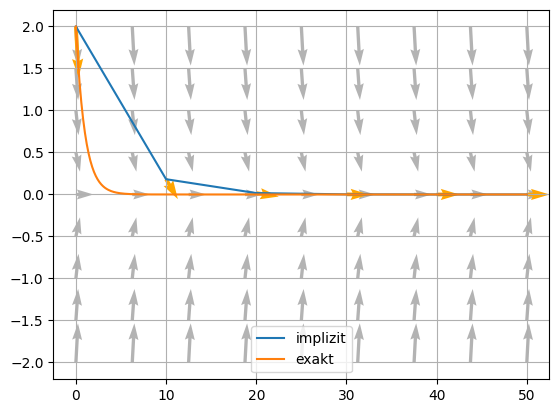

In [85]:
# y' = - a * y
a = 1


h = 10. # Schrittweite

# Darstellung des Vektorfeldes
x, y = np.linspace(0, np.max((5, 5*h)),9), np.linspace(-2, 2,9)
X, Y = np.meshgrid(x,y)
plt.quiver(X, Y, np.ones_like(X), - a * Y, angles = "xy", color = [.7,.7,.7])

y0 = 2
n = int( (x[-1] - x[0]) / h + 1)
k = np.arange(n)

xe = np.linspace(x[0], x[-1], n)
xi = xe
# für diese Dgl kann man direkt berechnen, was Eulers Methoden ergeben würden, s. Skript
ye = y0 * (1 - a * h)**k           # Euler explizit (direkt berechnet)
yi = y0 * (1 + a * h)**(-k)        # Euler implizit (direkt berechnet)

yexact = lambda x: y0 * np.exp(-a*x) # exakte Lösung

# plt.quiver(xe, ye, np.ones_like(xe), - a * ye, angles = "xy", color = "blue")
plt.quiver(xi, yi, np.ones_like(xi), - a * yi, angles = "xy", color = "orange")
# plt.plot(xe, ye, label = "explizit")
plt.plot(xe, yi, label = "implizit")
xx = np.linspace(xe[0], xe[-1], 500)
plt.plot(xx, yexact(xx), label = "exakt")
plt.grid()
plt.legend()

ode-solver haben eine Schrittweitensteuerung, die die Schrittweite $h$ auf Grund einer Fehlerschätzung anpasst, d.h. die Solver bleiben stabil. Das Problem ist aber, dass die **Rechenzeit** unter Umständen sehr lang wird.

### Implementierung des impliziten Verfahrens

In [86]:
# Newton-Verfahren 
def newton(g, dg, s, maxit = 100):
    delta = 1
    it = 0
    while np.abs(delta) > 1e-10 and it < maxit:
        delta = g(s) / dg(s)  
        s -= delta
        it += 1
    return s
    
#%% Euler (rückwärts) Achtung: es ist nicht garantiert, dass die Endstelle xn exakt getroffen wird!
def eulerImplizit(f, d2f, x0, y0, xn, h):
    
    x = [x0]
    y = [y0]
    
    while x[-1] < xn-h/2:
        x.append(x[-1] + h)
        g  = lambda s: y[-1] + h * f(x[-1], s) - s
        dg = lambda s: h * d2f(x[-1], s) - 1
        yn = newton(g, dg, y[-1] + h/2 * f(x[-1], y[-1]))
        y.append( yn )
    return np.array(x), np.array(y)

### explizite und implizite Methode im Vergleich
Die gDgl $y' = \sin(x + y)$ übernehmen wir aus dem ersten Beispiel

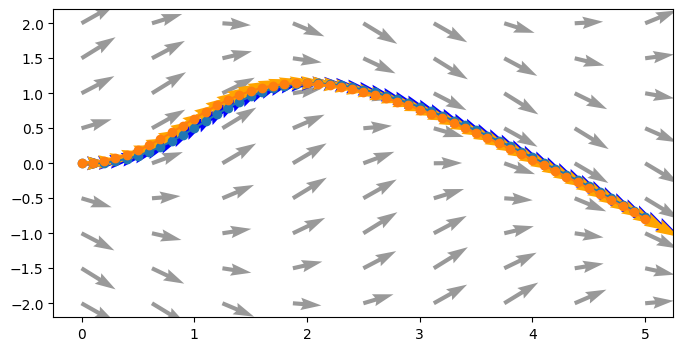

In [88]:
f   = lambda x, y :  np.sin(x+y)  # y' = f(x, y)
d2f = lambda x, y :  np.cos(x+y)  # partielle Ableitung df / dy. Wird für die implizite Eulermethode verwendet

x, y = np.linspace(0,5,9), np.linspace(-2, 2,9)
X, Y = np.meshgrid(x,y)

y0 = 0
x0 = 0
h = 0.1

xe, ye = eulerExplizit(f, x0, y0, xn = x[-1], h = h)
xi, yi = eulerImplizit(f, d2f, x0, y0, xn = x[-1], h = h)

plt.figure(figsize = (8, 4))
plt.quiver(X, Y, u(X,Y), v(X,Y), angles = 'xy', linewidth = .25, color = [.6,.6,.6])
plt.plot(xe, ye, 'o-')
plt.plot(xi, yi, 'o-')
plt.quiver(xe, ye, u(xe,ye), v(xe,ye), angles = 'xy', linewidth = .25, color = "b")
plt.quiver(xi, yi, u(xi,yi), v(xi,yi), angles = 'xy', linewidth = .25, color = "orange")

Ein Beispiel zur Illustration des Stabilitätsproblems ist die ODE

$$
    y' = y^2 \cdot (1 - y), \,\,\,y(0) = 0.1
$$

Die ode ist separierbar mit der exakten Lösung

$$
    x = c + \ln \left( \frac{y}{1 - y} \right) - \frac{1}{y}
$$

die nicht elementar nach $y$ umgestellt werden kann. Sobald die Lösungskurve "nahe" bei der konstanten Lösung $y = 1$ angelangt ist, ist die Lösungskurve fast eine Gerade und man würde eigentlich gerne eine "grosse" Schrittweite $h$ verwenden. 


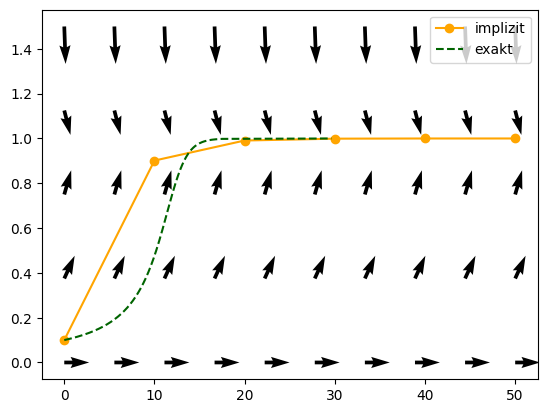

In [94]:
f = lambda x, y: y**2 * (1 - y)
d2f = lambda x, y: 2 * y - 3 * y**2 # np.ones_like(x) - 2 * y

x = np.linspace(0, 50, 10)
y = np.linspace(0, 1.5, 5)

X, Y = np.meshgrid(x, y)

x0 = 0
y0 = 0.1

h = 10.

xe, ye = eulerExplizit(f = f, x0 = x0, y0 = y0, xn = x[-1], h = h)
xi, yi = eulerImplizit(f, d2f, x0, y0, xn = x[-1], h = h)

c = x0 - np.log(y0 / (1 - y0)) + 1/y0 

yex = np.linspace(y0, 1-1e-8, 500)
xex = c + np.log(yex / (1 - yex) ) - 1/yex

plt.quiver(X, Y, u(X, Y), v(X, Y), angles = "xy")
# plt.plot(xe, ye, 'o-', label = "explizit", color = "blue")
plt.plot(xi, yi, 'o-', label = "implizit", color = "orange")
plt.plot(xex, yex, '--', label = "exakt", color = "darkgreen")
plt.legend()

### Praxisbeispiel
Hier ein Praxisbeispiel mit python-ode Solvern für den sogenannten **Van der Pol-Oszillator**

$$
    y'' - \mu \cdot (1 - y^2) \cdot y' + y = 0
$$

Die gDgl ist hier zweiter Ordnung und wird (s. AN3) auf ein System erster Ordnung umgeschrieben.

\begin{eqnarray*}
    y_1' &=& y_2 \\
    y_2' &=& \mu \cdot (1 - y_1^2) \cdot y_2 - y_1
\end{eqnarray*}

Der Parameter $\mu > 0$ beeinflusst die Numerik: je grösser, desto eher ist ein impliziter Solver angebracht.



mu =  1 	Methode:  RK45 	 t =  541.0  ms
mu =  10 	Methode:  RK45 	 t =  1256.0  ms
mu =  100 	Methode:  RK45 	 t =  8185.0  ms
mu =  300 	Methode:  RK45 	 t =  25419.0  ms

mu =  1 	Methode:  Radau 	 t =  2942.0  ms
mu =  10 	Methode:  Radau 	 t =  3258.0  ms
mu =  100 	Methode:  Radau 	 t =  668.0  ms
mu =  300 	Methode:  Radau 	 t =  257.0  ms


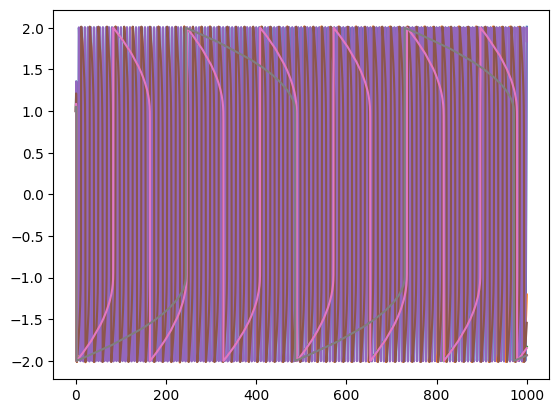

In [95]:
from scipy.integrate import solve_ivp 
import time

f = lambda x, y: np.array([y[1], mu * (1 - y[0]**2) * y[1] - y[0]])

y0 = [1.,1]
x0 = 0

mus = (1, 10, 100, 300)
methods = ("RK45", "Radau") # RK4 ist explizit, Radau ist implizit

for method in methods:
    print()
    for mu in mus:
        print("mu = ", mu, "\tMethode: ", method, "\t", end = " ")
        start = time.time()
        sol = solve_ivp(f, [0, 1000], y0, method = method)
        end = time.time()
        print("t = ", np.round(1000 * (end - start)), " ms")
        plt.plot(sol.t, sol.y[0])